In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
import interpolation_lcl as interp
from constants import epsilon, A_1,alpha,g,R_dry
import updraft_emmanuel
from autoconversion_rate import thresh
import autoconversion_rate as ar
from GB84_eqs import f as flux, rho_m
from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow


c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading the Data

In [2]:
#choose time period of runs
slice_str = "2024-07-16 00:00:00, 2024-07-16 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

In [3]:
#load the datasets -radiometer profiles
cabauw_data = xr.open_mfdataset(r'..\data\model_inputs\Cabauw_radiometer\radiometer_profile_data.nc')
cabauw_data = cabauw_data.sel(time=slice(*slice_tuple))

In [4]:

time = cabauw_data.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

In [5]:
T_air = cabauw_data.temperature.values
p = cabauw_data.pressure.values
T_d = cabauw_data.dew_point_temperature.values
q_v = cabauw_data.specific_humidity.values
Z = cabauw_data.height.values

#### Parsivel rainfall data

In [6]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

In [7]:
rows = T_air.shape[0]
cols = T_air.shape[1]

## empty arrays for storing the meteorological profiles
T_arr = np.zeros(T_air.shape) #parcel temperature profile (time, height)
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
T_air_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


In [8]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_l'  # choose which approach to follow for the conserved potential temperature

for i in range(0,rows):
    print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.Temp_prof(T_air[i,0],p[i,0],T_d[i],p[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], T_air_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p[i],Z,int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.T_v(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65


In [9]:
# environmental virtual temperature profile
T_v_env = T_air_new*(1+0.61*q_v_new)

### Cloud Heights

In [10]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0


In [23]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.cloud_top(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])


### Updraft speed

In [35]:
#import updraft_emmanuel

#empty array for saving updraft velocities
w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)
         
    w_parcel_max[i],CAPE = updraft_emmanuel.w_parcel(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],p_t[i],top_index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65


### State calculation and update

In [36]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = rho_m(T_s[i],T_air_new[i,top_index],p_s[i],p_t[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = flux(T_d[i],p_new[i,0],p_t[i],T_air_new[i,top_index],rho,w_avg)

    if i<rows-1:
        if X[i]/Z_c[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.autoconoversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i] - outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])


0
1
9999.0 7063.875389151995 8955.433020358469 7063.875389151995 8955.433020358469
2
2
9999.0 6046.690797595926 8835.122029626498 6046.690797595926 8835.122029626498
2
3
9999.0 6805.0771658682515 8807.11073978374 6805.0771658682515 8807.11073978374
2
4
9999.0 6523.541069735345 8803.84717228942 6523.541069735345 8803.84717228942
2
5
9999.0 6533.180112584921 8752.48391031642 6533.180112584921 8752.48391031642
2
6
9999.0 6829.9222952957 8663.573474671628 6829.9222952957 8663.573474671628
2
7
9999.0 7361.471728727144 8861.934369322644 7361.471728727144 8861.934369322644
2
8
9999.0 7372.029033689386 8789.115343816362 7372.029033689386 8789.115343816362
2
9
9999.0 6797.917948825908 8845.238217525224 6797.917948825908 8845.238217525224
2
10
9999.0 7641.900798893412 8883.161928783591 7641.900798893412 8883.161928783591
2
11
12
13
14
15
559.0 331.0813946414482 478.780791375092 331.0813946414482 478.780791375092
2
16
17
18
759.0 378.37512059865867 651.8952410913366 378.37512059865867 651.8952410

#### Rainfall rates

In [37]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.autoconoversion_rate(X[i],Z_c[i],thresh)
    if R[i]<=(0.1/3600):#or Z_c[i]<=3000:
        P[i] = 0
    else:
        print(i)
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_air_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_D_c()
        P[i] = nr.precipitation_rate(ar.autoconoversion_rate(X[i],Z_c[i],thresh), mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

1
-1.0289101038192825 7.730011446789085
2
-1.1145612551687183 7.009900558664971
3
-1.005977741972755 7.923052091832042
4
-1.041019500237221 7.628117123653145
5
-1.018456871635393 7.817992493193637
6
-0.9377551666746475 8.497932484477078
7
-0.8583383285969262 9.168267198269515
8
-0.8908712009511892 8.893519786645369
9
-0.7328815363448833 10.229694370666751
10
-0.8729929253549771 9.044480587811634
14
-0.5715190365995884 11.599409492943186
15
10.810847273226422 126.29910579786308
18
11.688996496684993 137.39971676276096
20
1.2568496202148134 27.491996715228655
22
-1.2032644263147665 6.265596082173329
23
-1.2359435480058405 5.991761290453787
24
-1.1657060998438342 6.580564826931555
25
-1.1542363615430977 6.676804563273589
26
-0.5744467298517122 11.57451248500217
27
-1.2514989755666068 5.861485125252785
28
-1.288494401857827 5.551832256946885
29
-1.327494541848882 5.225677585720549
30
-1.2633061664250733 5.762630663823151
31
-1.1616755090091972 6.614381683424956
32
-1.3363351652450584 5.151

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

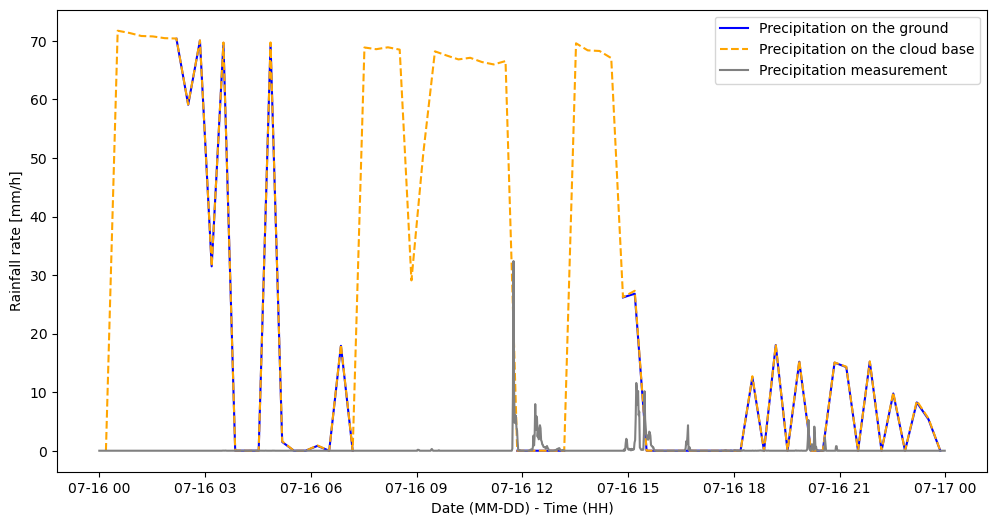

In [38]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

#### Virtual Temperature profiles at different times

In [39]:
nearest_time = '2024-07-19T00'
selected = time.sel(time=nearest_time, method='nearest')

# Get the index of the nearest time
index_1 = int(time.get_index('time').get_loc(selected.time.values))

nearest_time_2 = '2024-07-19T12'
selected_2 = time.sel(time=nearest_time_2, method='nearest')

# Get the index of the nearest time
index_2 = int(time.get_index('time').get_loc(selected_2.time.values))

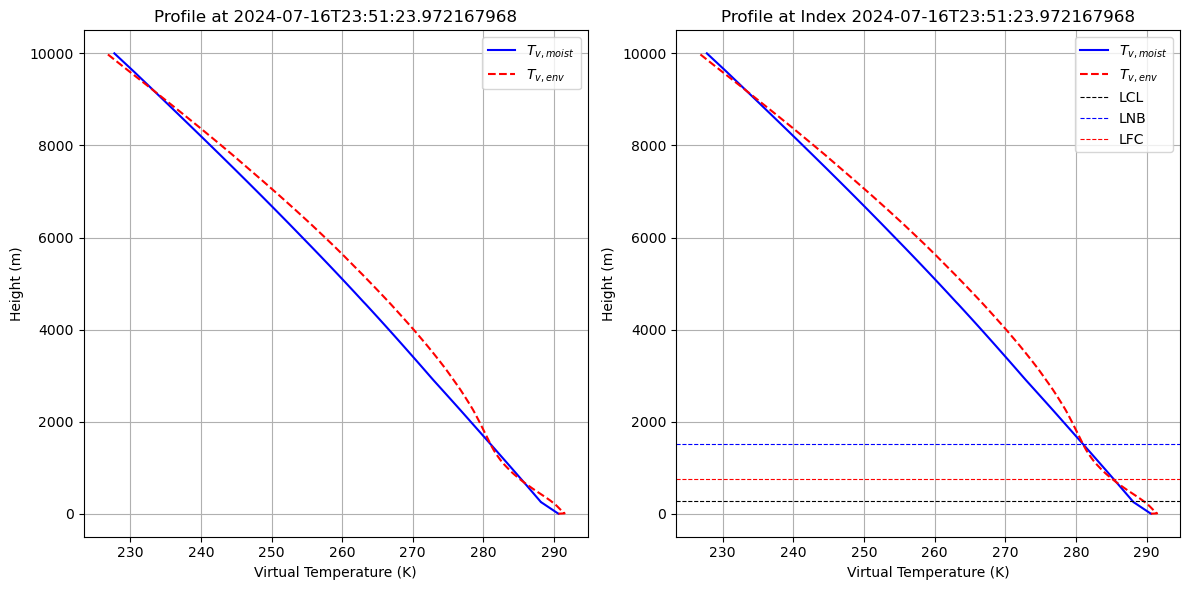

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
index_1 = index_1
index_2 = index_2

# Subplot 1: For index 1
ax1.plot(T_v_moist[index_1], Z_new[index_1], label='$T_{v,moist}$', color='blue')
ax1.plot(T_air_new[index_1] * (1 + 0.61 * q_v_new[index_1]), Z_new[index_1], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax1.set_xlabel('Virtual Temperature (K)')
ax1.set_ylabel('Height (m)')
ax1.set_title(f'Profile at {time[index_1].values}')
ax1.legend()
ax1.grid(True)

# Subplot 2: For index 2
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(T_air_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Prevents overlapping labels
plt.show()
#plt.ylim(Z[lcl_index],Z[LFC_index[1]+2])#,Z[LFC_index[1]+2])
#plt.ylim(0,100#### Cloud top and base0)

#### Cloud top and base

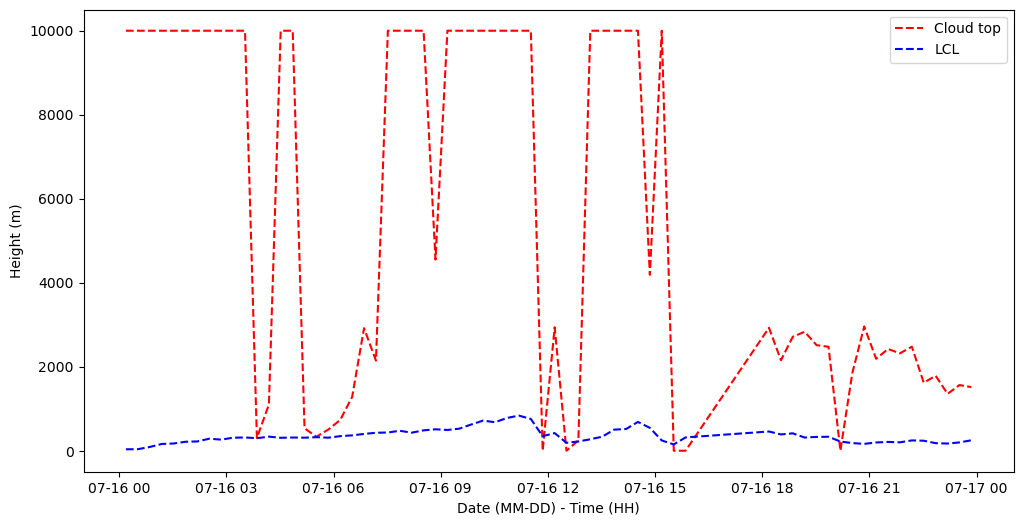

In [41]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Date (MM-DD) - Time (HH)')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

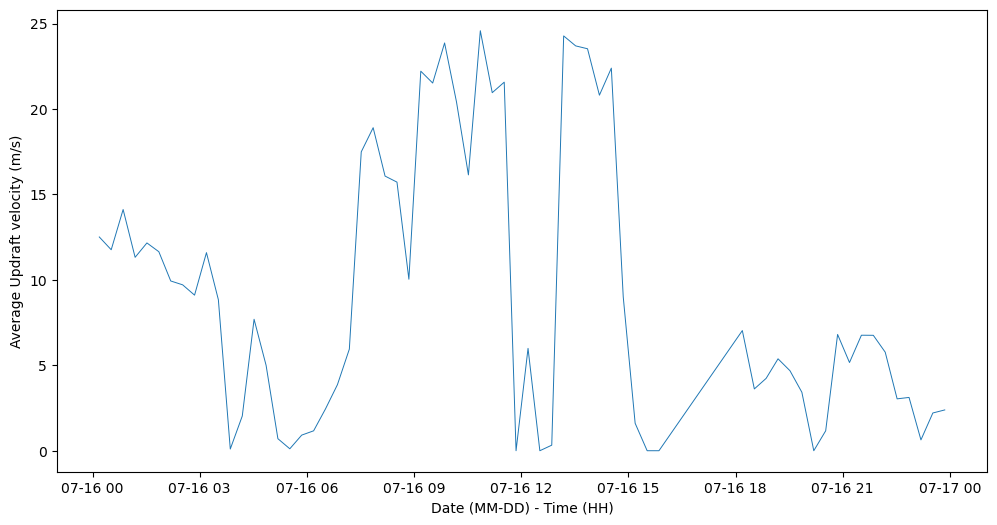

In [42]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

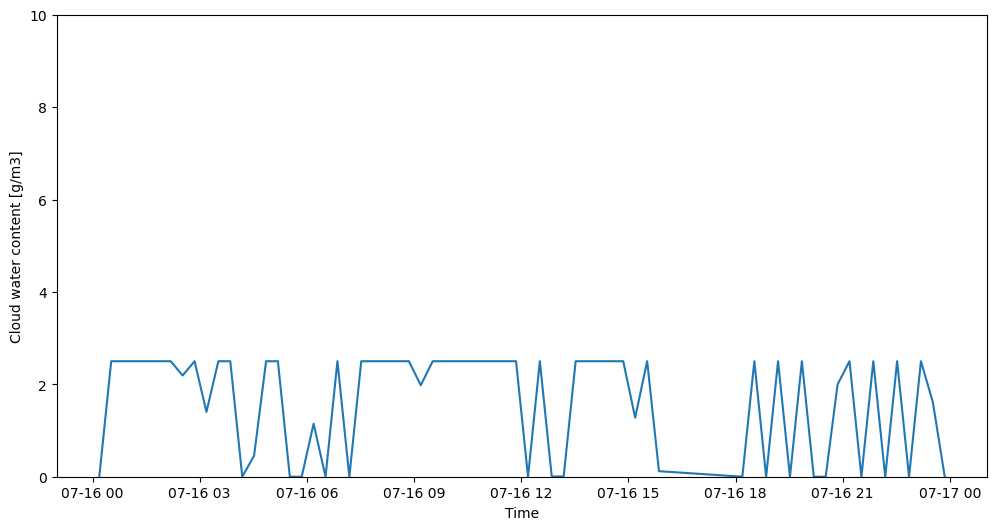

In [43]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

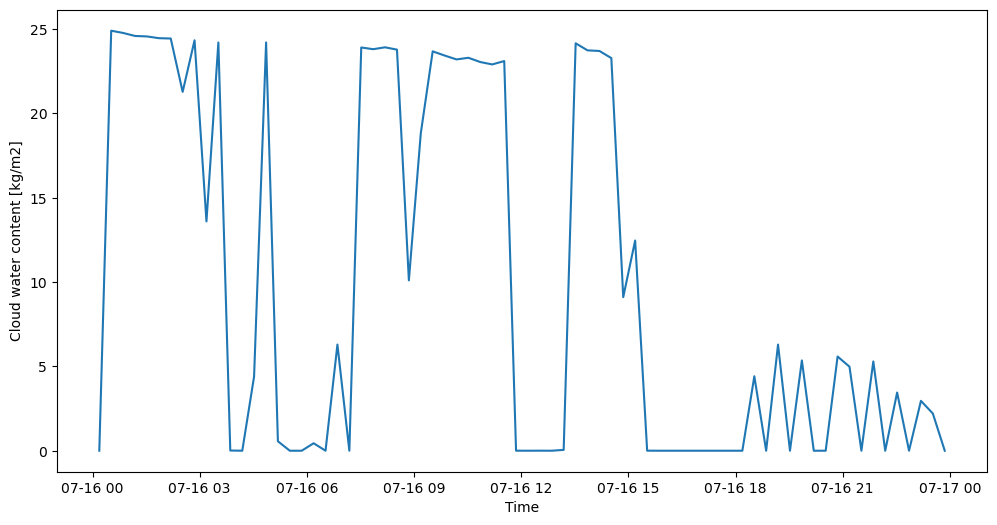

In [44]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

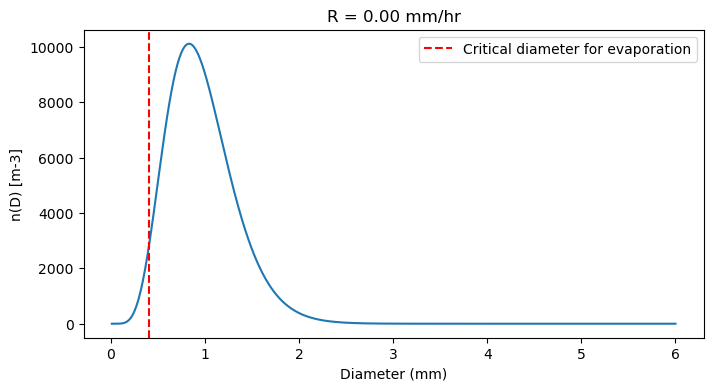

In [45]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()